In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/master_ecommerce.csv")

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [2]:
customer_metrics = (
    df.groupby("customer_unique_id").agg({
        "order_id": "nunique",
        "payment_value": "sum",
        "order_purchase_timestamp": ["min", "max"]
    })
)
    


In [3]:
customer_metrics.columns = [
    "Total_Orders",
    "Total_Revenue",
    "First_Purchase",
    "Last_Purchase"
]

customer_metrics.head()

,Total_Orders,Total_Revenue,First_Purchase,Last_Purchase
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42


In [4]:
customer_metrics["Customer_Lifespan_Days"] = (customer_metrics["Last_Purchase"] - customer_metrics["First_Purchase"]).dt.days

In [5]:
customer_metrics["Customer_Lifespan_Days"] = customer_metrics["Customer_Lifespan_Days"].replace(0,1)

In [6]:
customer_metrics["AOV"] = (customer_metrics["Total_Revenue"] / customer_metrics["Total_Orders"])

In [7]:
purchase_frequency = (
    customer_metrics["Total_Orders"].sum() / len(customer_metrics)
)

print(purchase_frequency)

1.0330925875644854


CLV = AOV * Purchase Frequency

In [8]:
customer_metrics["CLV"] = (customer_metrics["AOV"] * purchase_frequency)

In [9]:
top_customers = (customer_metrics.sort_values("CLV", ascending=False).head(10))

top_customers

,Total_Orders,Total_Revenue,First_Purchase,Last_Purchase,Customer_Lifespan_Days,AOV,CLV
customer_unique_id,,,,,,,
0a0a92112bd4c708ca5fde585afaa872,1,109312.64,2017-09-29 15:24:52,2017-09-29 15:24:52,1,109312.64,112930.078111
698e1cf81d01a3d389d96145f7fa6df8,1,45256.00,2017-08-23 09:22:34,2017-08-23 09:22:34,1,45256.00,46753.638143
c402f431464c72e27330a67f7b94d4fb,1,44048.00,2018-02-22 15:30:41,2018-02-22 15:30:41,1,44048.00,45505.662297
4007669dec559734d6f53e029e360987,1,36489.24,2017-11-24 11:03:35,2017-11-24 11:03:35,1,36489.24,37696.763370
ef8d54b3797ea4db1d63f0ced6a906e9,1,30186.00,2018-04-19 13:54:06,2018-04-19 13:54:06,1,30186.00,31184.932848
763c8b1c9c68a0229c42c9fc6f662b93,1,29099.52,2018-07-15 14:49:44,2018-07-15 14:49:44,1,29099.52,30062.498414
3d47f4368ccc8e1bb4c4a12dbda7111b,1,22346.60,2017-10-02 15:49:23,2017-10-02 15:49:23,1,22346.60,23086.106817
adfa1cab2b2c8706db21bb13c0a1beb1,1,19457.04,2018-06-01 19:08:41,2018-06-01 19:08:41,1,19457.04,20100.923800
1b76903617af13189607a36b0469f6f3,1,19174.38,2018-05-22 13:43:23,2018-05-22 13:43:23,1,19174.38,19808.909849


CLV Distribution

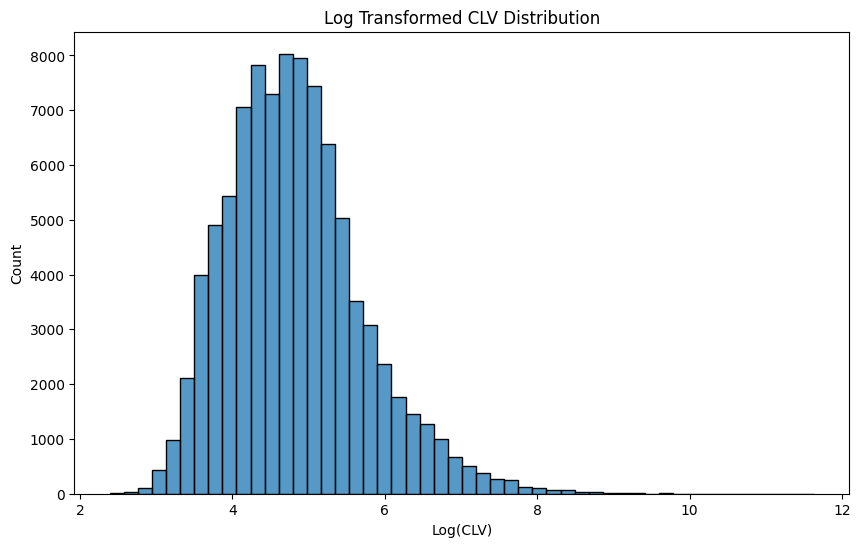

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(customer_metrics["CLV"]),
    bins=50
)

plt.title("Log Transformed CLV Distribution")

plt.xlabel("Log(CLV)")

plt.show()

In [12]:
customer_metrics["CLV_Segment"] = pd.qcut(customer_metrics["CLV"], 4, labels=[
    "Low Value",
    "Medium Value",
    "High Value",
    "VIP"
])

In [16]:
clv_revenue = (
    customer_metrics
    .groupby("CLV_Segment")["Total_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(clv_revenue)

CLV_Segment
VIP             12972758.94
High Value       3515702.07
Medium Value     2014343.69
Low Value        1026809.84
Name: Total_Revenue, dtype: float64


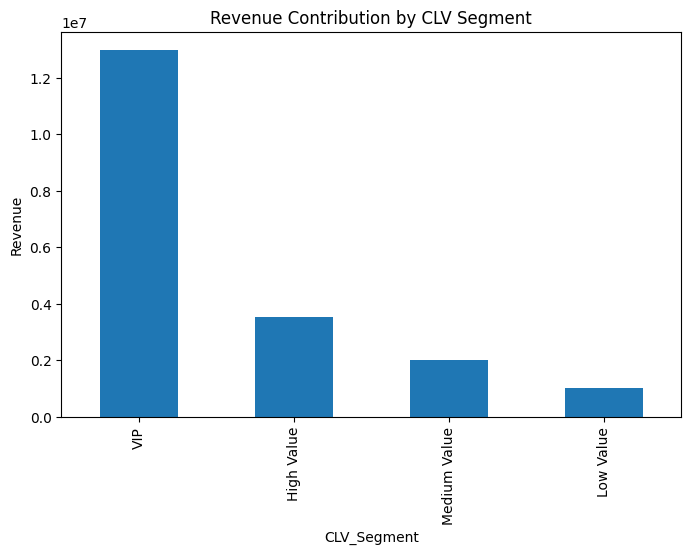

In [17]:
plt.figure(figsize=(8,5))

clv_revenue.plot(kind="bar")

plt.title("Revenue Contribution by CLV Segment")
plt.ylabel("Revenue")

plt.show()

In [19]:
customer_metrics.to_csv(
    "../data/customer_clv.csv"
)

1. CLV Distribution Shows a Classic Long-Tail Pattern

The log-transformed distribution is approximately bell-shaped, indicating that:

Most customers generate moderate lifetime value.
A small number of customers generate exceptionally high value.
Customer spending behavior is highly unequal across the customer base.
Business Implication

A relatively small percentage of customers contribute a disproportionately large share of revenue.

2. VIP Customers Drive Revenue

This is the most important finding.

Your revenue contribution chart shows:

VIP >>> High Value > Medium Value > Low Value

VIP customers contribute significantly more revenue than every other segment.

Business Implication

The business is heavily dependent on retaining its highest-value customers.

Losing even a small percentage of VIP customers could have a noticeable impact on revenue.

Recommended Actions
VIP loyalty programs
Early access to sales
Personalized recommendations
Dedicated customer support
3. Revenue Concentration Exists

Although customer counts are evenly distributed due to quartile segmentation:

pd.qcut()

Revenue is not evenly distributed.

The VIP segment contributes multiple times the revenue generated by Low Value customers.

Business Implication

Customer acquisition efforts should focus on attracting customers similar to existing VIP customers.

4. High Value Customers Are the Next Growth Opportunity

High Value customers already generate substantial revenue but have not yet reached VIP status.

Recommended Actions
Upselling
Product bundles
Personalized offers
Cross-selling campaigns

Converting High Value customers into VIP customers can significantly increase profitability.

5. Low Value Customers Show Limited Revenue Impact

Low Value customers contribute the smallest share of total revenue.

Business Implication

Aggressive retention spending on these customers may not generate positive ROI.

Retention budgets should be prioritized toward:

VIP Customers
High Value Customers
Potential Loyalists

Executive Summary

Customer Lifetime Value analysis revealed a highly concentrated revenue structure where VIP customers generate the majority of business revenue. While most customers contribute moderate lifetime value, a small subset of customers drives disproportionate financial impact. The findings highlight the importance of retaining VIP customers, nurturing High Value customers, and implementing targeted engagement strategies to maximize long-term customer profitability.